# Piecewise potential vorticity inversion on the sphere

This notebook runs one inversion from beginning to end and plots what each step
produced. It uses the ERA5 blocking case that ships with the package.

The question the inversion answers is: **of the anomalous rotational wind at
250 hPa, how much was induced by the potential vorticity anomaly at each level,
and how much by the potential temperature anomaly at the ground?**

The steps are

1. the event and the climatology it is an anomaly against
2. the vertical coordinate, and potential temperature
3. the streamfunction, from the wind
4. Ertel potential vorticity
5. the anomaly that will be inverted
6. extending the hemisphere to the sphere
7. the solve
8. the wind induced by each level
9. the same, grouped into surface, lower and upper
10. what the pieces add up to, and what is left over

Every figure is written to `figures/` and is the one the documentation shows.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))

from pvinv_sph.config import InversionConfig, MirrorConfig
from pvinv_sph.levels import CP, KAPPA, P0, build_levels
from pvinv_sph.passab import ertel_pv_pvu
from pvinv_sph.passd import invert_pieces
from pvinv_sph.prepare import prepare_state
from pvinv_sph.sht import SHT, gaussian_grid
from pvinv_sph.sphere import SphereOps
from pvinv_sph.winds import rotational_wind_stack

DATA = Path.cwd().parents[1] / "data"
FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "savefig.bbox": "tight"})
TARGET = 250.0            # the level the induced wind is reported on
CASE = "era5_blocking"
DISC = 40.0               # radius of the disc drawn about an event, in degrees

In [2]:
# Every map in this notebook is drawn about the event rather than about the
# earth's axis: the frame is rotated so the event is at the pole of the
# projection, and a disc of fixed great-circle radius is shown.  Every event then
# has the same geometry whatever its latitude, and the earth's pole is an ordinary
# point inside the picture rather than a place where the coordinates fail.
import cartopy.crs as ccrs
import matplotlib.path as mpath

_CIRCLE = mpath.Path(
    np.c_[np.sin(np.linspace(0, 2 * np.pi, 200)),
          np.cos(np.linspace(0, 2 * np.pi, 200))] * 0.5 + 0.5
)

def event_axes(fig, spec, lat0, lon0, radius=DISC, title=None):
    "One circular panel centred on the event, with coastlines."
    ax = fig.add_subplot(
        spec,
        projection=ccrs.AzimuthalEquidistant(
            central_longitude=float(lon0), central_latitude=float(lat0)
        ),
    )
    ax.set_boundary(_CIRCLE, transform=ax.transAxes)
    metres = radius * 111.195e3
    ax.set_xlim(-metres, metres)
    ax.set_ylim(-metres, metres)
    ax.coastlines(linewidth=0.45, color="0.3")
    ax.gridlines(linewidth=0.3, color="0.6", alpha=0.7,
                 ylocs=range(0, 91, 15), xlocs=range(-180, 181, 30))
    if title:
        ax.set_title(title, fontsize=9)
    return ax

def shade(ax, field, lat, lon, **kwargs):
    "Colour a field on such a panel, closing the longitude seam."
    return ax.pcolormesh(
        np.append(lon, 360.0), lat, np.c_[field, field[:, :1]],
        transform=ccrs.PlateCarree(), shading="auto", **kwargs
    )

def fill(ax, field, lat, lon, levels, **kwargs):
    "The same, as filled contours, for fields with a clear level structure."
    return ax.contourf(
        np.append(lon, 360.0), lat, np.c_[field, field[:, :1]], levels,
        transform=ccrs.PlateCarree(), extend="both", **kwargs
    )

def arrows(ax, u, v, lat, lon, scale=300.0):
    return ax.quiver(lon, lat, u, v, transform=ccrs.PlateCarree(),
                     regrid_shape=18, scale=scale, width=0.005, color="0.15")

def mark(ax, lat0, lon0):
    ax.plot(lon0, lat0, "c*", markersize=13, markeredgecolor="k",
            markeredgewidth=0.7, transform=ccrs.PlateCarree(), zorder=6)
    ax.plot(0.0, 90.0, "o", color="white", markersize=5, markeredgecolor="k",
            markeredgewidth=0.8, transform=ccrs.PlateCarree(), zorder=6)

## 1. The event and its climatology

The inversion works on an anomaly, so it needs two states: the event and the
climatology for the same day and hour. Both cover the whole northern hemisphere,
because a global inversion has no lateral boundary to stop at.

In [3]:
event_ds = xr.open_dataset(DATA / f"{CASE}.nc")
clim_ds = xr.open_dataset(DATA / f"{CASE}_clim.nc")
centre = json.loads((DATA / "events.json").read_text())[CASE]
lat0, lon0 = centre["lat"], centre["lon"]

lat = event_ds["lat"].values          # ascending, 0 to 90 N
lon = event_ds["lon"].values          # ascending, from 0
plev = event_ds["level"].values       # 1000 hPa first

print(f"{CASE}: {centre['time']}, centre {lat0:.1f} N {lon0:.1f} E")
print(f"grid {lat.size} x {lon.size}, levels {plev.astype(int)}")

def fields(ds):
    "Height, temperature and the two wind components, bottom-up."
    return tuple(np.asarray(ds[v].values, float) for v in ("z", "t", "u", "v"))

z_ev, t_ev, u_ev, v_ev = fields(event_ds)
z_cl, t_cl, u_cl, v_cl = fields(clim_ds)
k250 = int(np.where(plev == TARGET)[0][0])
k500 = int(np.where(plev == 500)[0][0])

era5_blocking: 2025-01-08T00:00:00, centre 43.5 N 226.5 E
grid 61 x 240, levels [1000  850  700  500  400  300  250  200  100]


height anomaly at the centre: 272 m


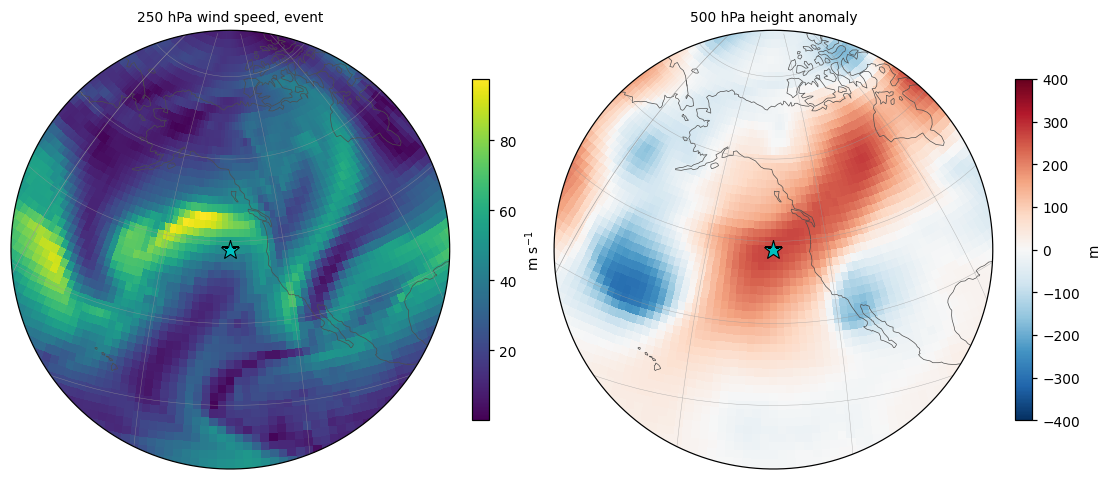

In [4]:
anom = z_ev[k500] - z_cl[k500]
fig = plt.figure(figsize=(10, 4.4), constrained_layout=True)
grid = fig.add_gridspec(1, 2)

ax = event_axes(fig, grid[0, 0], lat0, lon0,
                title=f"{TARGET:.0f} hPa wind speed, event")
m = shade(ax, np.hypot(u_ev[k250], v_ev[k250]), lat, lon, cmap="viridis")
mark(ax, lat0, lon0)
fig.colorbar(m, ax=ax, shrink=0.75, label="m s$^{-1}$")

ax = event_axes(fig, grid[0, 1], lat0, lon0, title="500 hPa height anomaly")
lim = float(np.abs(anom).max())
m = shade(ax, anom, lat, lon, cmap="RdBu_r", vmin=-lim, vmax=lim)
mark(ax, lat0, lon0)
fig.colorbar(m, ax=ax, shrink=0.75, label="m")
fig.savefig(FIGURES / "fig01_event.png")
print(f"height anomaly at the centre: "
      f"{anom[np.argmin(abs(lat-lat0)), np.argmin(abs(lon-lon0))]:.0f} m")

## 2. The vertical coordinate, and potential temperature

The inversion uses the Exner function as its vertical coordinate,

$$\Pi = c_p \left(\frac{p}{p_0}\right)^{\kappa}, \qquad \kappa = R_d/c_p = 2/7,$$

because hydrostatic balance is then simply $\partial\Phi/\partial\Pi = -\theta$,
with no coefficient in the way. $\Pi$ *decreases* upward, so every vertical
difference below carries that sign.

Potential temperature is formed here, from temperature. Supplying potential
temperature instead would leave the state wrong by one factor of the Exner
function, and it would still look entirely plausible.

In [5]:
levels = build_levels("NL9")
assert np.allclose(levels.p_hpa, plev), "the data must be on the levels the solver uses"

print("pressure [hPa]:", levels.p_hpa.astype(int))
print("Pi [J/kg/K]   :", np.round(levels.pi, 1))
print(f"Pi decreases upward, so every vertical difference carries that sign; "
      f"the spacing runs from {abs(levels.pi[1]-levels.pi[0]):.0f} at the bottom "
      f"to {abs(levels.pi[-1]-levels.pi[-2]):.0f} at the top.")

pressure [hPa]: [1000  850  700  500  400  300  250  200  100]
Pi [J/kg/K]   : [1004.5  958.9  907.2  824.   773.1  712.1  676.   634.2  520.3]
Pi decreases upward, so every vertical difference carries that sign; the spacing runs from 46 at the bottom to 114 at the top.


## 3. The streamfunction, from the wind

The balance system is written in the streamfunction, so the first thing to do with
the wind is take its rotational part. On the sphere that is one spectral operation:
the vorticity comes from the wind directly, and

$$\nabla^2\psi = \zeta$$

is inverted by dividing each spherical-harmonic coefficient by $-n(n+1)/a^2$.
There is no relaxation and no boundary condition to choose, because there is no
boundary — the only mode without an inverse is the global constant, which carries
no wind.

The solver grid is Gaussian and excludes the poles, so no metric factor is ever
divided by at a singular point.

rotational wind at 250 hPa: rms 31.0 m/s
full wind at 250 hPa      : rms 29.8 m/s


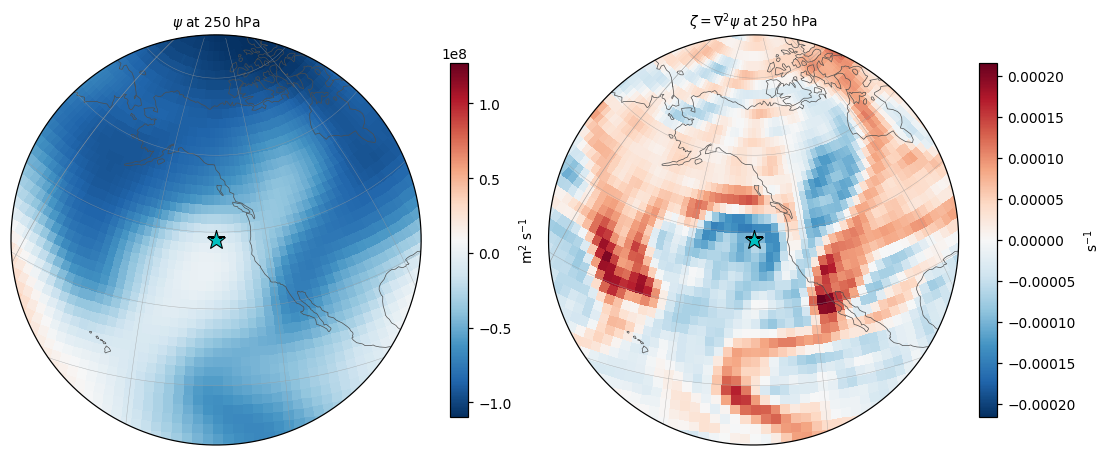

In [6]:
solver = SphereOps(SHT(gaussian_grid(96, 192), lmax=63))
config = InversionConfig(mirror=MirrorConfig(blend=True))

event = prepare_state(z_ev, t_ev, u_ev, v_ev, lat, lon, levels, solver)
clim = prepare_state(z_cl, t_cl, u_cl, v_cl, lat, lon, levels, solver)

slat, slon = solver.grid.lat, solver.grid.lon
north = slat > 0
psi250 = solver.synth(event.psi_spec[k250])
zeta250 = event.zeta[k250]

fig = plt.figure(figsize=(10, 4.4), constrained_layout=True)
grid = fig.add_gridspec(1, 2)
ax = event_axes(fig, grid[0, 0], lat0, lon0, title=r"$\psi$ at 250 hPa")
m = shade(ax, psi250, slat, slon, cmap="RdBu_r")
mark(ax, lat0, lon0)
fig.colorbar(m, ax=ax, shrink=0.75, label="m$^2$ s$^{-1}$")

ax = event_axes(fig, grid[0, 1], lat0, lon0,
                title=r"$\zeta = \nabla^2\psi$ at 250 hPa")
lim = float(np.abs(zeta250[north]).max())
m = shade(ax, zeta250, slat, slon, cmap="RdBu_r", vmin=-lim, vmax=lim)
mark(ax, lat0, lon0)
fig.colorbar(m, ax=ax, shrink=0.75, label="s$^{-1}$")
fig.savefig(FIGURES / "fig02_streamfunction.png")

u_rot, v_rot = rotational_wind_stack(solver, event.psi_spec)
print(f"rotational wind at 250 hPa: rms {np.sqrt(np.mean(u_rot[k250][north]**2 + v_rot[k250][north]**2)):.1f} m/s")
print(f"full wind at 250 hPa      : rms {np.sqrt(np.mean(u_ev[k250]**2 + v_ev[k250]**2)):.1f} m/s")

## 4. Ertel potential vorticity

The quantity being inverted is the hydrostatic Ertel potential vorticity,

$$q = -g\left[(f+\zeta)\frac{\partial\theta}{\partial p}
      + \frac{\partial u}{\partial p}\frac{\partial\theta}{\partial y}
      - \frac{\partial v}{\partial p}\frac{\partial\theta}{\partial x}\right],$$

which the solver carries in the form the balance equations need,

$$\hat q = (f+\nabla^2\psi)\frac{\partial^2\Phi}{\partial\Pi^2}
         - \nabla_h\!\left(\frac{\partial\psi}{\partial\Pi}\right)\cdot
           \nabla_h\!\left(\frac{\partial\Phi}{\partial\Pi}\right).$$

The two differ by a single factor per level, so what is plotted below is in the
familiar potential vorticity units.

Interior potential vorticity exists on levels 850 to 200 hPa only. The vertical
derivative needs a level on each side, so at 1000 and 100 hPa there is none — those
two levels carry **boundary potential temperature** instead, which enters the
inversion as a condition rather than as a source.

levels carrying interior PV: [850 700 500 400 300 250 200]
levels carrying boundary theta: [1000, 100]


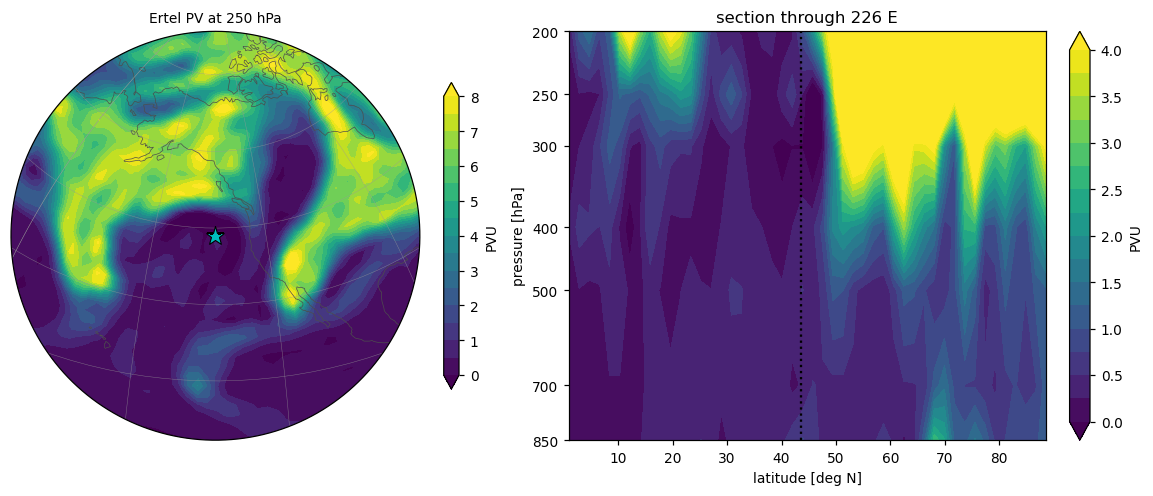

In [7]:
pv = ertel_pv_pvu(event.q_hat, levels)
interior = levels.interior
kq = list(interior).index(k250)

fig = plt.figure(figsize=(11, 4.4), constrained_layout=True)
grid = fig.add_gridspec(1, 2)
ax = event_axes(fig, grid[0, 0], lat0, lon0, title=f"Ertel PV at {TARGET:.0f} hPa")
m = fill(ax, pv[kq], slat, slon, np.arange(0.0, 8.1, 0.5), cmap="viridis")
mark(ax, lat0, lon0)
fig.colorbar(m, ax=ax, shrink=0.75, label="PVU")

axes = [ax, fig.add_subplot(grid[0, 1])]
i0 = np.argmin(abs(slon - lon0))
section = np.array([pv[i][:, i0] for i in range(len(interior))])
m = axes[1].contourf(slat[north], levels.p_hpa[interior], section[:, north],
                     np.linspace(0, 4, 17), cmap="viridis", extend="both")
axes[1].invert_yaxis(); axes[1].set_yscale("log")
axes[1].set_yticks([850, 700, 500, 400, 300, 250, 200])
axes[1].set_yticklabels([850, 700, 500, 400, 300, 250, 200])
axes[1].minorticks_off()
axes[1].set_xlabel("latitude [deg N]"); axes[1].set_ylabel("pressure [hPa]")
axes[1].set_title(f"section through {lon0:.0f} E")
axes[1].axvline(lat0, color="k", ls=":")
fig.colorbar(m, ax=axes[1], label="PVU")
fig.savefig(FIGURES / "fig03_pv.png")
print("levels carrying interior PV:", levels.p_hpa[interior].astype(int))
print("levels carrying boundary theta:", [int(levels.p_hpa[0]), int(levels.p_hpa[-1])])

## 5. The anomaly to be inverted

Subtracting the climatology gives the sources: an interior potential vorticity
anomaly on each of the seven interior levels, and a potential temperature anomaly
on each of the two boundaries. Those nine things are the pieces. Nothing else
drives the inversion.

In [8]:
q_anom = ertel_pv_pvu(event.q_hat - clim.q_hat, levels)
theta_bot_anom = event.theta_bot - clim.theta_bot
theta_top_anom = event.theta_top - clim.theta_top

# The nine sources are plotted further down, each beside the wind it induces,
# which is where they mean something.
print(f"PV anomaly at {TARGET:.0f} hPa: min {q_anom[kq][north].min():.2f}, max {q_anom[kq][north].max():.2f} PVU")

PV anomaly at 250 hPa: min -5.54, max 7.76 PVU


## 6. Extending the hemisphere to the sphere

The data are northern-hemisphere only; the operator is global. The extension has
to keep the inversion elliptic and must not let the invented hemisphere leak into
the answer, and one choice does both: reflect everything as an **even** function of
latitude and use $|f|$.

With even coefficients and even sources the operator commutes with a reflection
about the equator, so the solution is exactly even, and its northern half solves
the northern problem under a condition of no meridional gradient at the equator.
The southern half is then determined by the northern one and carries no
information of its own.

Two details matter. The wind is mirrored **as a vector** first — eastward even,
northward odd — and its vorticity taken; only then is that vorticity mirrored as
an even scalar. Mirroring the wind and stopping there would leave $\zeta$ odd, so
$|f| + \zeta$ would change sign across the equator and ellipticity would be lost.
And $|f|$ has a corner at the equator, which is smoothed by a floor.

   10.5 N: f*/|f| = 1.52, taper weight = 0.26
   20.0 N: f*/|f| = 1.17, taper weight = 1.00
   30.0 N: f*/|f| = 1.08, taper weight = 1.00
   45.0 N: f*/|f| = 1.04, taper weight = 1.00


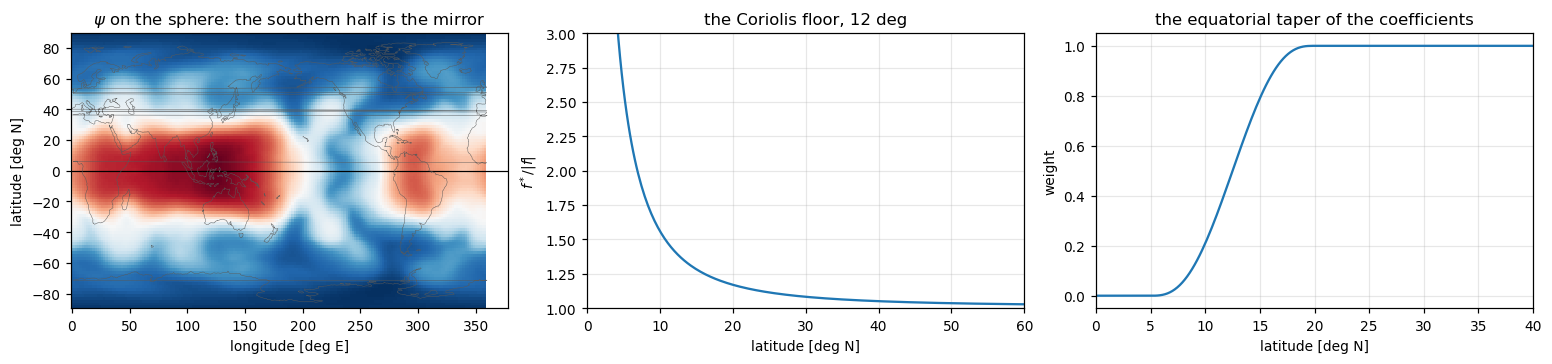

In [9]:
from pvinv_sph.mirror import blend_weight, coriolis_star

fig, axes = plt.subplots(1, 3, figsize=(14, 3.2), constrained_layout=True)
axes[0].pcolormesh(slon, slat, solver.synth(event.psi_spec[k250]), cmap="RdBu_r",
                   shading="auto")
axes[0].axhline(0, color="k", lw=0.8)
try:                                    # coastlines, drawn straight on the axes
    import cartopy.feature as cfeature
    for geom in cfeature.COASTLINE.geometries():
        for line in (geom.geoms if hasattr(geom, "geoms") else [geom]):
            xy = np.asarray(line.coords)
            axes[0].plot(xy[:, 0] % 360.0, xy[:, 1], color="0.35", lw=0.3)
except Exception:
    pass
axes[0].set_title(r"$\psi$ on the sphere: the southern half is the mirror")
axes[0].set_xlabel("longitude [deg E]"); axes[0].set_ylabel("latitude [deg N]")

deg = np.linspace(0, 90, 400)
axes[1].plot(deg, coriolis_star(deg, 12.0) / (2 * 7.292115e-5 * np.sin(np.radians(np.maximum(deg, 1e-6)))))
axes[1].set_xlim(0, 60); axes[1].set_ylim(1, 3)
axes[1].set_xlabel("latitude [deg N]"); axes[1].set_ylabel(r"$f^*/|f|$")
axes[1].set_title("the Coriolis floor, 12 deg")
axes[1].grid(alpha=0.3)

axes[2].plot(deg, blend_weight(deg, 5.0, 20.0))
axes[2].set_xlim(0, 40)
axes[2].set_xlabel("latitude [deg N]"); axes[2].set_ylabel("weight")
axes[2].set_title("the equatorial taper of the coefficients")
axes[2].grid(alpha=0.3)
fig.savefig(FIGURES / "fig04_mirror.png")

for d in (10.5, 20.0, 30.0, 45.0):
    r = float(coriolis_star(np.array([d]), 12.0)[0]) / (2 * 7.292115e-5 * np.sin(np.radians(d)))
    print(f"  {d:5.1f} N: f*/|f| = {r:.2f}, taper weight = {float(blend_weight(np.array([d]))[0]):.2f}")

## 7. The solve

Two equations are solved together for the perturbation geopotential and
streamfunction: the balance equation, and the potential vorticity equation
linearised about the mean plus half the perturbation. That midpoint is not an
approximation — for a quadratic system it is exact — and it is what makes the
pieces add up.

The total balanced state is found first, by a Newton iteration whose Jacobian is
the same operator the pieces use. Each linear solve is preconditioned by a
separable approximation: the horizontal part is diagonal in spherical-harmonic
space and the vertical part is a small tridiagonal system for each coefficient.

Newton: 11 steps, converged True, final increment 0.065 m
Krylov iterations per piece: {'1000': 55, '850': 42, '700': 46, '500': 46, '400': 45, '300': 49, '250': 52, '200': 51, '100': 47}
clamped fraction: 0.0000
elapsed: 141 s


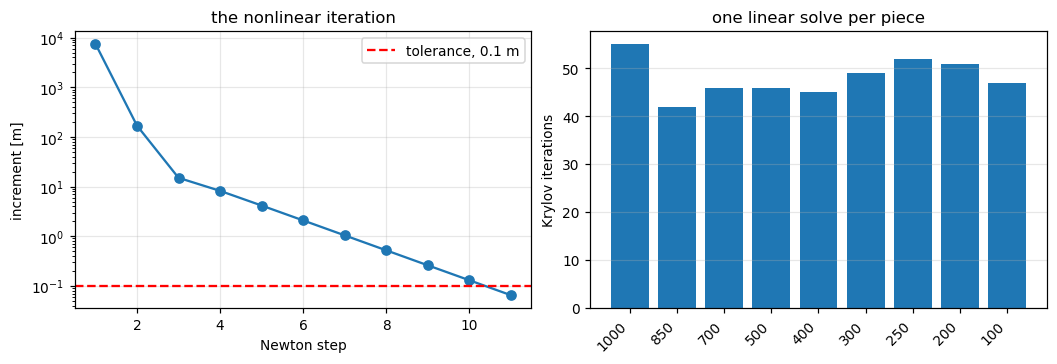

In [10]:
import time

started = time.time()
result = invert_pieces(solver, levels, clim, event, cfg=config)
elapsed = time.time() - started

report = result.diagnostics
print(f"Newton: {result.newton_steps} steps, converged {report['newton_converged']}, "
      f"final increment {report['newton_final_increment_m']:.3f} m")
print(f"Krylov iterations per piece: {report['linear_iterations']}")
print(f"clamped fraction: {result.clamp_worst:.4f}")
print(f"elapsed: {elapsed:.0f} s")

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2), constrained_layout=True)
axes[0].semilogy(np.arange(1, len(report["newton_increments"]) + 1),
                 np.array(report["newton_increments"]) / 9.81, "o-")
axes[0].axhline(0.1, color="r", ls="--", label="tolerance, 0.1 m")
axes[0].set_xlabel("Newton step"); axes[0].set_ylabel("increment [m]")
axes[0].set_title("the nonlinear iteration"); axes[0].legend(); axes[0].grid(alpha=0.3)

names = list(report["linear_iterations"])
axes[1].bar(range(len(names)), [report["linear_iterations"][n] for n in names])
axes[1].set_xticks(range(len(names))); axes[1].set_xticklabels(names, rotation=45, ha="right")
axes[1].set_ylabel("Krylov iterations"); axes[1].set_title("one linear solve per piece")
axes[1].grid(alpha=0.3, axis="y")
fig.savefig(FIGURES / "fig05_convergence.png")

## 8. The wind induced by each level

This is the result. Each panel is the rotational wind at 250 hPa that would exist
if the only anomaly in the atmosphere were the one on that level, with everything
else at its climatological value.

The two boundary panels are potential temperature anomalies; the other seven are
potential vorticity anomalies.

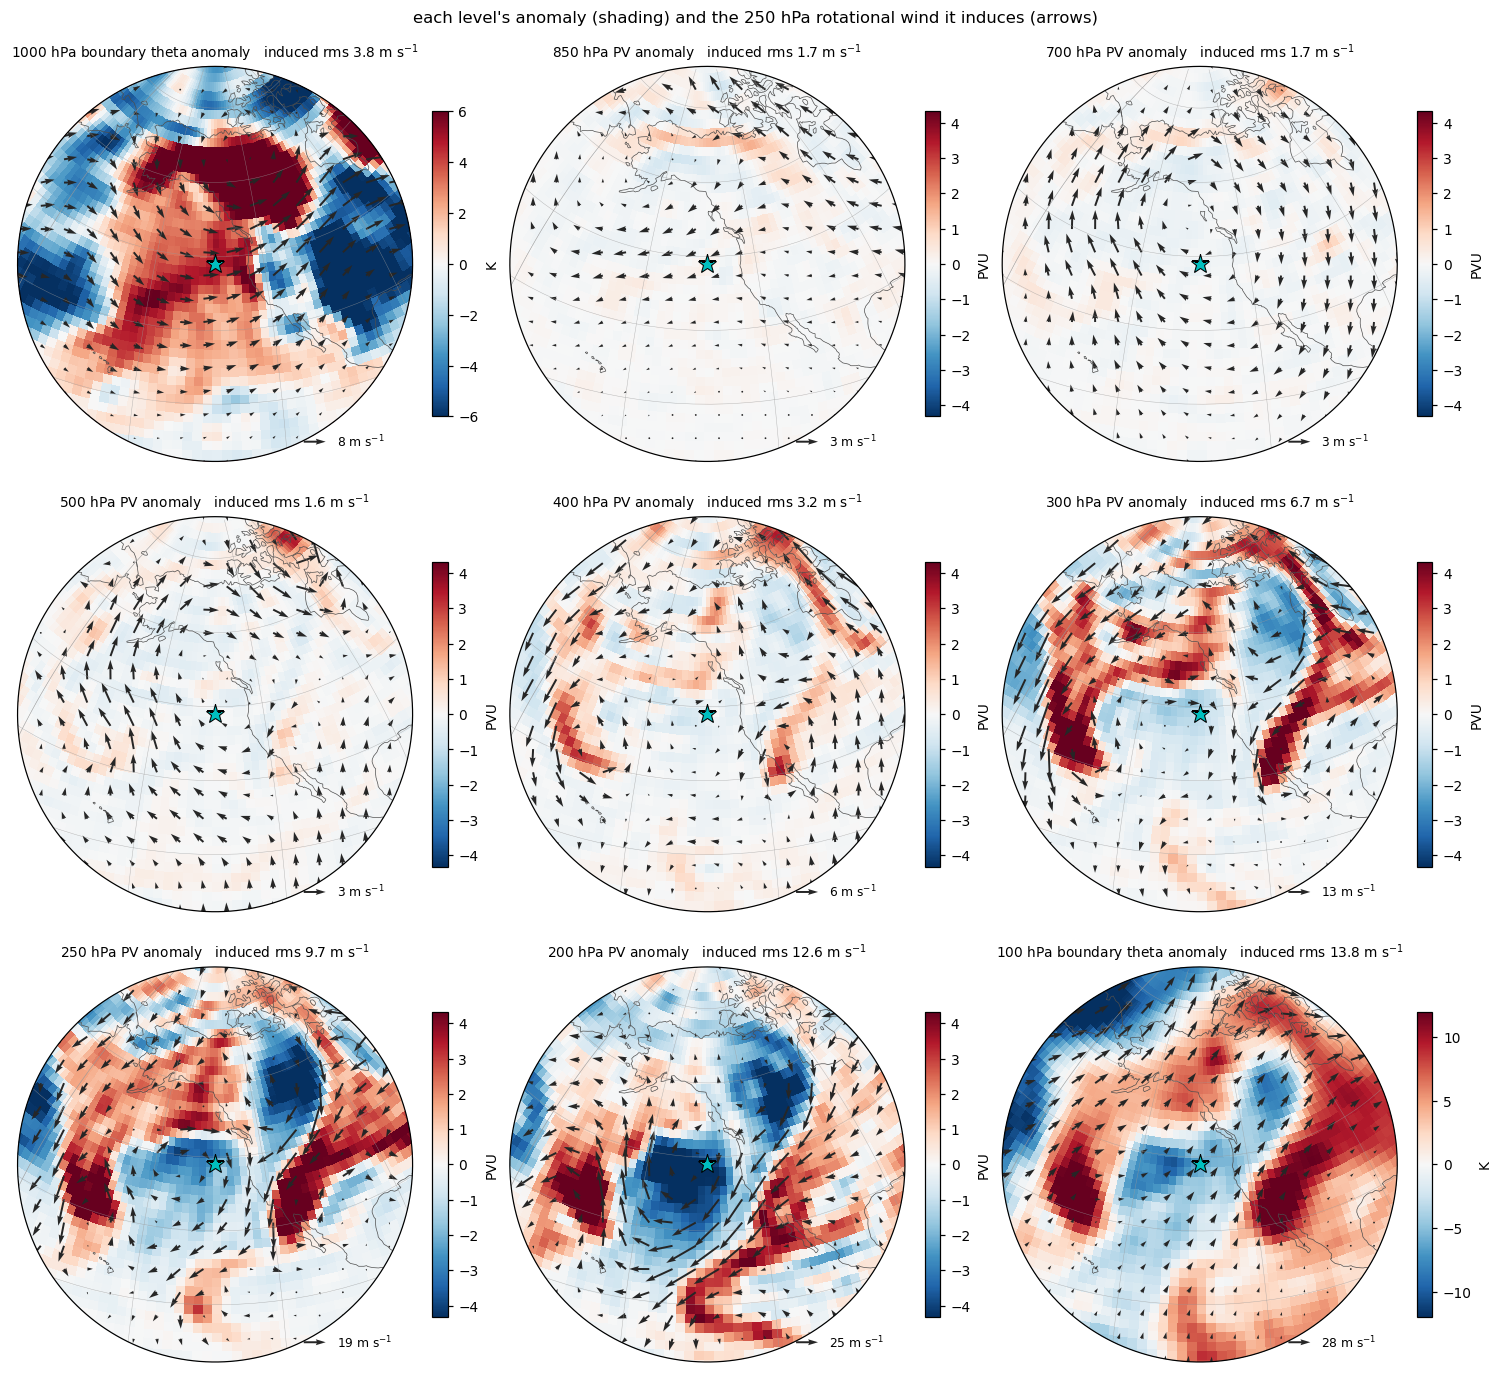

In [11]:
def induced(piece_name):
    "Rotational wind at the target level induced by one piece."
    u, v = rotational_wind_stack(solver, result.pieces[piece_name].psi_spec)
    return u[k250], v[k250]

# Each panel pairs a source with what it induces: the shading is the anomaly that
# drives the piece -- potential vorticity on the seven interior levels, potential
# temperature on the two boundaries -- and the arrows are the wind it produces at
# the target level.  Those are different quantities in different units, so the
# arrow scale is set panel by panel and written on each one; comparing arrow
# lengths between panels means reading the keys.
order = [str(int(p)) for p in levels.p_hpa]
sources = {order[0]: (theta_bot_anom, 6.0, "K"),
           order[-1]: (theta_top_anom, 12.0, "K")}
q_lim = float(np.percentile(np.abs(q_anom[:, north, :]), 99))
for i, k in enumerate(interior):
    sources[str(int(levels.p_hpa[k]))] = (q_anom[i], q_lim, "PVU")

fig = plt.figure(figsize=(13.5, 12.5), constrained_layout=True)
grid = fig.add_gridspec(3, 3)
for n, name in enumerate(order):
    u, v = induced(name)
    field, vlim, unit = sources[name]
    speed = np.hypot(u, v)
    rms = float(np.sqrt(np.mean(speed[north] ** 2)))
    kind = "boundary theta anomaly" if unit == "K" else "PV anomaly"
    ax = event_axes(fig, grid[n // 3, n % 3], lat0, lon0,
                    title=f"{name} hPa {kind}   induced rms {rms:.1f} m s$^{{-1}}$")
    m = shade(ax, field, slat, slon, cmap="RdBu_r", vmin=-vlim, vmax=vlim)
    # One arrow length per panel, scaled to that panel's own strength, so a weak
    # piece stays legible instead of vanishing beside a strong one.
    key = max(1.0, float(np.round(2 * rms)))
    handle = arrows(ax, u, v, slat, slon, scale=18.0 * key)
    ax.quiverkey(handle, 0.78, 0.05, key, f"{key:.0f} m s$^{{-1}}$",
                 labelpos="E", coordinates="axes", fontproperties={"size": 8})
    mark(ax, lat0, lon0)
    fig.colorbar(m, ax=ax, shrink=0.72, label=unit)
fig.suptitle(f"each level's anomaly (shading) and the {TARGET:.0f} hPa rotational "
             f"wind it induces (arrows)")
fig.savefig(FIGURES / "fig06_per_level.png")

## 9. Grouped into surface, lower and upper

Nine panels is more than the eye can hold, and the usual question is coarser: how
much of the upper-level flow came from below, and how much from the upper
troposphere? The pieces are linear in their sources, so they can simply be added:

* **surface** — the 1000 hPa boundary potential temperature
* **lower** — potential vorticity at 850, 700 and 500 hPa
* **upper** — potential vorticity at 400, 300, 250 and 200 hPa, together with the
  100 hPa boundary potential temperature

The three groups exhaust the sources, so they sum to the same thing the nine
panels do.

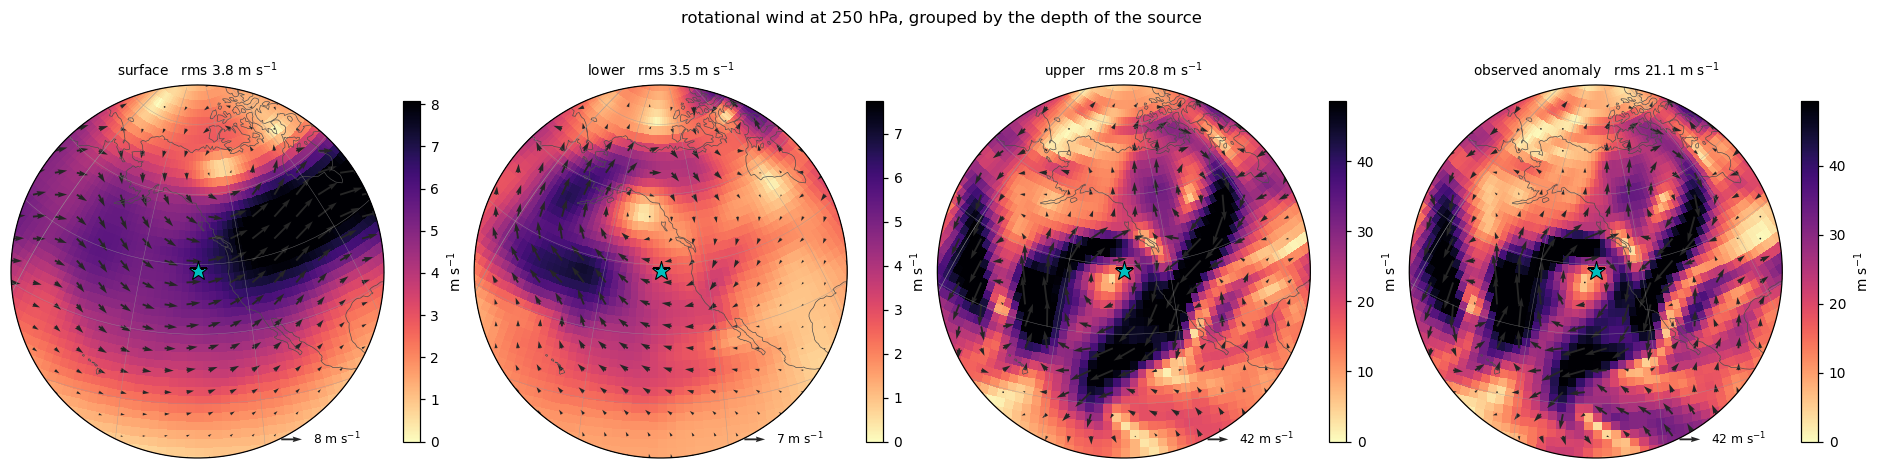

In [12]:
GROUPS = {
    "surface": ["1000"],
    "lower": ["850", "700", "500"],
    "upper": ["400", "300", "250", "200", "100"],
}

def group_wind(names):
    total = sum(result.pieces[n].psi_spec for n in names)
    u, v = rotational_wind_stack(solver, total)
    return u[k250], v[k250]

u_obs, v_obs = rotational_wind_stack(solver, event.psi_spec - clim.psi_spec)
u_obs, v_obs = u_obs[k250], v_obs[k250]

panels = [(name, *group_wind(names)) for name, names in GROUPS.items()]
panels.append(("observed anomaly", u_obs, v_obs))
fig = plt.figure(figsize=(17, 4.6), constrained_layout=True)
grid = fig.add_gridspec(1, 4)
for col, (name, u, v) in enumerate(panels):
    speed = np.hypot(u, v)
    rms = float(np.sqrt(np.mean(speed[north] ** 2)))
    ax = event_axes(fig, grid[0, col], lat0, lon0,
                    title=f"{name}   rms {rms:.1f} m s$^{{-1}}$")
    # Colour and arrows are both scaled to the panel's own strength.  The groups
    # differ by a factor of six here, and one shared scale would leave two of the
    # four blank; the numbers in the titles are what to compare across panels.
    vmax = float(np.percentile(speed[north], 98))
    m = shade(ax, speed, slat, slon, cmap="magma_r", vmin=0, vmax=vmax)
    # The colour scale is shared so the panels can be compared; the arrows are
    # scaled panel by panel so a weak group is still readable beside a strong one.
    key = max(1.0, float(np.round(2 * rms)))
    handle = arrows(ax, u, v, slat, slon, scale=18.0 * key)
    ax.quiverkey(handle, 0.78, 0.05, key, f"{key:.0f} m s$^{{-1}}$",
                 labelpos="E", coordinates="axes", fontproperties={"size": 8})
    mark(ax, lat0, lon0)
    fig.colorbar(m, ax=ax, shrink=0.72, label="m s$^{-1}$")
fig.suptitle(f"rotational wind at {TARGET:.0f} hPa, grouped by the depth of the source")
fig.savefig(FIGURES / "fig07_groups.png")

## 10. What the pieces add up to

Two checks close the calculation.

The first is arithmetic: the nine pieces must reproduce the inversion of all the
sources at once. They are solved separately against one frozen operator, and the
system is linear in the sources, so this holds to the solver's tolerance and not
merely approximately. If it did not, the decomposition would mean nothing.

The second is physical: the sum of the pieces against the observed anomalous
rotational wind. What is left over is the part the balance equations do not
represent — the divergent and unbalanced flow. It is not an error, and its size
is worth knowing.

sum of pieces vs all sources at once: 7.12e-09  (converged True)
observed anomaly      21.09 m/s
sum of the pieces     20.21 m/s
left over              3.07 m/s  (15 % of the anomaly)


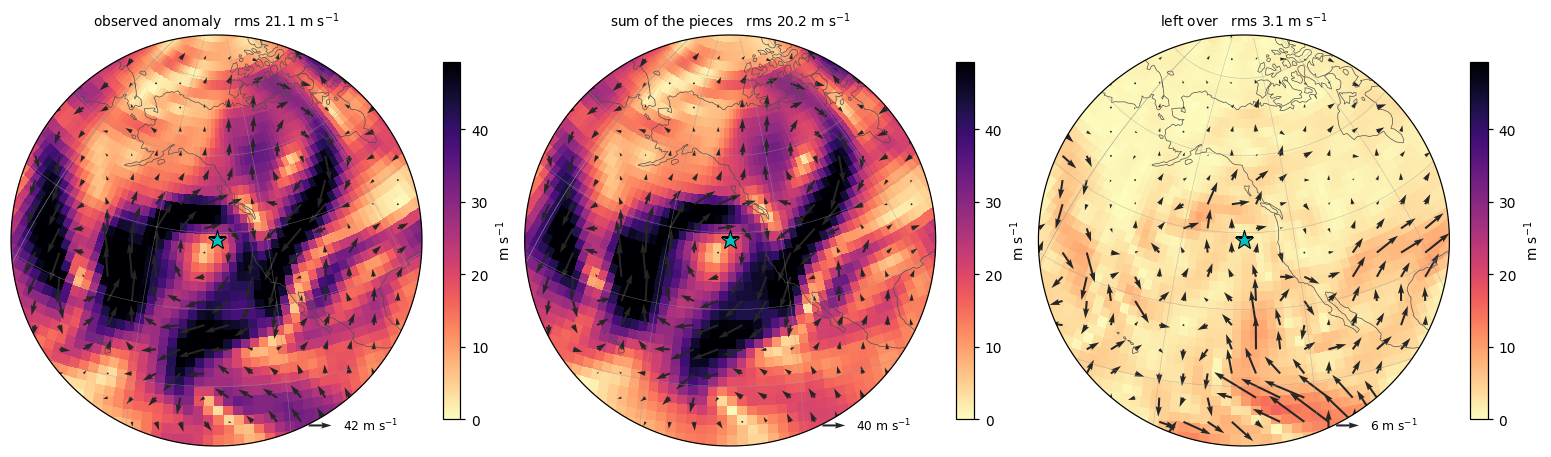

In [13]:
from pvinv_sph.passd import all_sources_inversion

summed = result.summed_psi()
total, total_report = all_sources_inversion(solver, levels, clim, event, cfg=config)
closure = np.abs(summed - total).max() / np.abs(total).max()
print(f"sum of pieces vs all sources at once: {closure:.2e}  (converged {total_report.converged})")

u_sum, v_sum = rotational_wind_stack(solver, summed)
u_sum, v_sum = u_sum[k250], v_sum[k250]
residual_u, residual_v = u_obs - u_sum, v_obs - v_sum

def rms(a, b):
    return float(np.sqrt(np.mean(a[north] ** 2 + b[north] ** 2)))

print(f"observed anomaly     {rms(u_obs, v_obs):6.2f} m/s")
print(f"sum of the pieces    {rms(u_sum, v_sum):6.2f} m/s")
print(f"left over            {rms(residual_u, residual_v):6.2f} m/s"
      f"  ({100 * rms(residual_u, residual_v) / rms(u_obs, v_obs):.0f} % of the anomaly)")

fig = plt.figure(figsize=(14, 4.6), constrained_layout=True)
grid = fig.add_gridspec(1, 3)
vmax = float(np.percentile(np.hypot(u_obs, v_obs)[north], 98))
for col, (name, u, v) in enumerate([("observed anomaly", u_obs, v_obs),
                                    ("sum of the pieces", u_sum, v_sum),
                                    ("left over", residual_u, residual_v)]):
    speed = np.hypot(u, v)
    rms = float(np.sqrt(np.mean(speed[north] ** 2)))
    ax = event_axes(fig, grid[0, col], lat0, lon0,
                    title=f"{name}   rms {rms:.1f} m s$^{{-1}}$")
    m = shade(ax, speed, slat, slon, cmap="magma_r", vmin=0, vmax=vmax)
    key = max(1.0, float(np.round(2 * rms)))
    handle = arrows(ax, u, v, slat, slon, scale=18.0 * key)
    ax.quiverkey(handle, 0.78, 0.05, key, f"{key:.0f} m s$^{{-1}}$",
                 labelpos="E", coordinates="axes", fontproperties={"size": 8})
    mark(ax, lat0, lon0)
    fig.colorbar(m, ax=ax, shrink=0.72, label="m s$^{-1}$")
fig.savefig(FIGURES / "fig08_closure.png")

## 11. The same calculation at 79 N

Nothing above referred to where the event was. The Greenland case that ships with
the package sits at 79 N, where half of a box drawn around it would lie across the
pole, and the calculation is the same one.

Newton: 10 steps, converged True


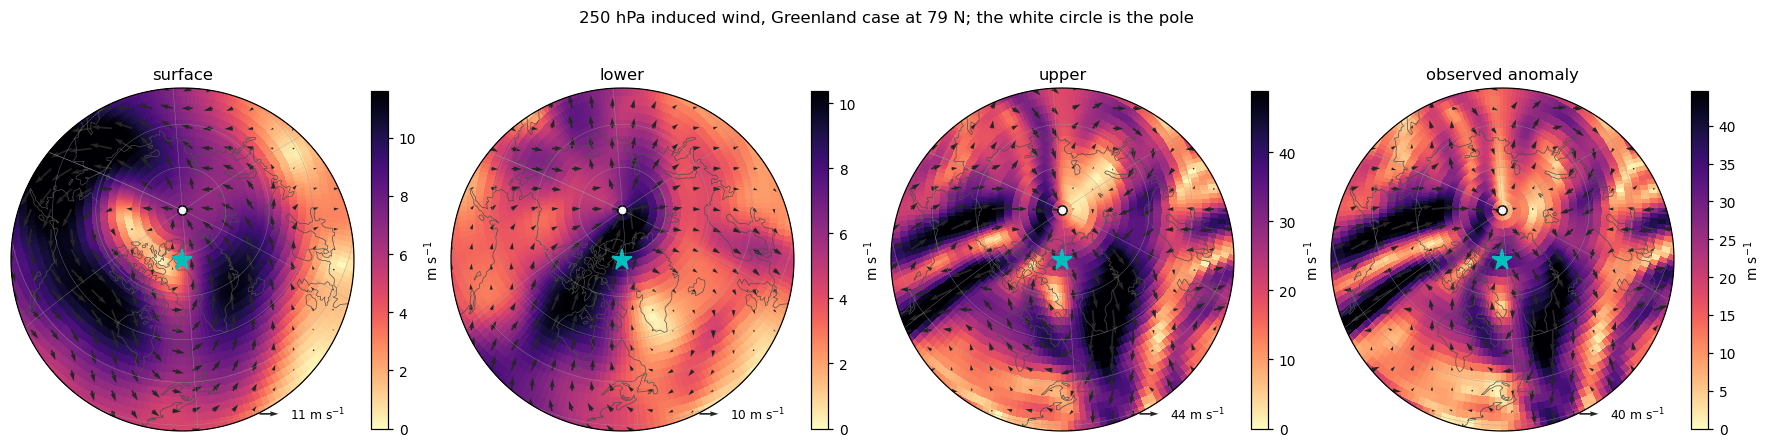

In [14]:
polar_ev = xr.open_dataset(DATA / "cesm_greenland.nc")
polar_cl = xr.open_dataset(DATA / "cesm_greenland_clim.nc")
polar_centre = json.loads((DATA / "events.json").read_text())["cesm_greenland"]

plat, plon = polar_ev["lat"].values, polar_ev["lon"].values
polar_solver = SphereOps(SHT(gaussian_grid(96, 192), lmax=63))
p_event = prepare_state(*fields(polar_ev), plat, plon, levels, polar_solver)
p_clim = prepare_state(*fields(polar_cl), plat, plon, levels, polar_solver)
p_result = invert_pieces(polar_solver, levels, p_clim, p_event, cfg=config)
print(f"Newton: {p_result.newton_steps} steps, "
      f"converged {p_result.diagnostics['newton_converged']}")

import cartopy.crs as ccrs
import matplotlib.path as mpath

plat_s, plon_s = polar_solver.grid.lat, polar_solver.grid.lon
theta_circle = np.linspace(0, 2 * np.pi, 200)
circle = mpath.Path(np.c_[np.sin(theta_circle), np.cos(theta_circle)] * 0.5 + 0.5)
projection = ccrs.AzimuthalEquidistant(central_longitude=polar_centre["lon"],
                                       central_latitude=polar_centre["lat"])

def polar_group(names):
    total = sum(p_result.pieces[n].psi_spec for n in names)
    u, v = rotational_wind_stack(polar_solver, total)
    return u[k250], v[k250]

u_pobs, v_pobs = rotational_wind_stack(polar_solver, p_event.psi_spec - p_clim.psi_spec)
panels = [(n, *polar_group(names)) for n, names in GROUPS.items()]
panels.append(("observed anomaly", u_pobs[k250], v_pobs[k250]))

fig = plt.figure(figsize=(16, 4.4), constrained_layout=True)
grid = fig.add_gridspec(1, 4)
for col, (name, u, v) in enumerate(panels):
    ax = fig.add_subplot(grid[0, col], projection=projection)
    ax.set_boundary(circle, transform=ax.transAxes)
    radius = 40.0 * 111.195e3
    ax.set_xlim(-radius, radius); ax.set_ylim(-radius, radius)
    speed = np.hypot(u, v)
    vmax = float(np.nanpercentile(speed[plat_s > 0], 98))
    m = ax.pcolormesh(np.append(plon_s, 360.0), plat_s,
                      np.c_[speed, speed[:, :1]], transform=ccrs.PlateCarree(),
                      cmap="magma_r", vmin=0, vmax=vmax, shading="auto")
    rms = float(np.sqrt(np.mean(speed[plat_s > 0] ** 2)))
    key = max(1.0, float(np.round(2 * rms)))
    handle = ax.quiver(plon_s, plat_s, u, v, transform=ccrs.PlateCarree(),
                       regrid_shape=18, scale=18.0 * key, width=0.005, color="0.15")
    ax.quiverkey(handle, 0.78, 0.05, key, f"{key:.0f} m s$^{{-1}}$",
                 labelpos="E", coordinates="axes", fontproperties={"size": 8})
    ax.plot(polar_centre["lon"], polar_centre["lat"], "c*", markersize=14,
            transform=ccrs.PlateCarree())
    ax.plot(0.0, 90.0, "o", color="white", markersize=6, markeredgecolor="k",
            transform=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.45, color="0.3")
    ax.gridlines(linewidth=0.3, color="0.6", alpha=0.7)
    ax.set_title(name)
    fig.colorbar(m, ax=ax, shrink=0.75, label="m s$^{-1}$")
fig.suptitle(f"{TARGET:.0f} hPa induced wind, Greenland case at "
             f"{polar_centre['lat']:.0f} N; the white circle is the pole")
fig.savefig(FIGURES / "fig09_polar.png")

The pole sits inside every panel and there is nothing special about it. That is
the whole point of doing the inversion globally: the method does not know where
the event is.